<a href="https://colab.research.google.com/github/Aakhil111/ai-image-generator/blob/main/Text_to_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install diffusers transformers accelerate torch

In [1]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

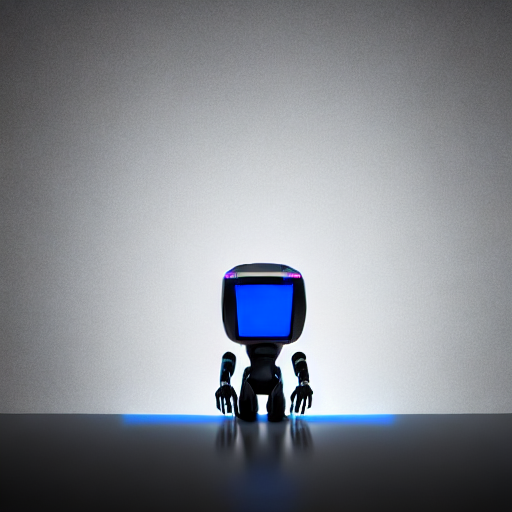

In [2]:
prompt = "A futuristic AI robot sitting in a dark room with glowing blue lights, cinematic lighting, ultra realistic, 8k"

image = pipe(prompt).images[0]

image

In [3]:
from google.colab import files

  0%|          | 0/50 [00:00<?, ?it/s]

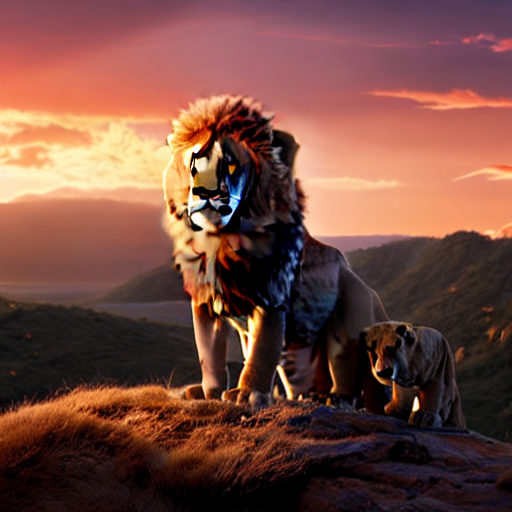

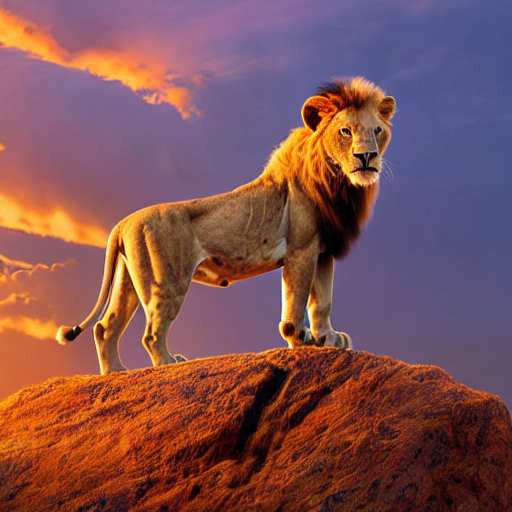

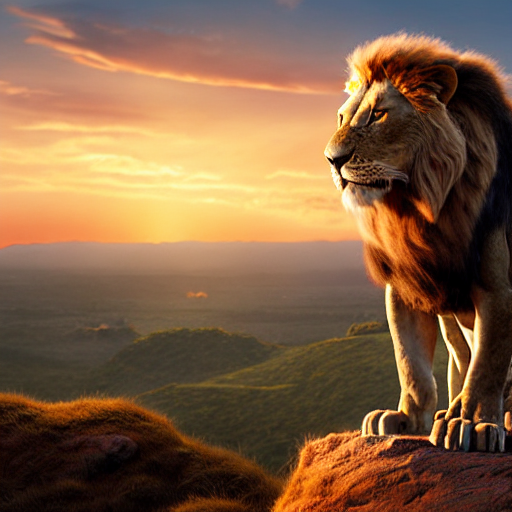

In [6]:
prompt = "A lion king standing on a rock, sunset, cinematic lighting, ultra realistic, 4k, highly detailed"

images = pipe(prompt, num_images_per_prompt=3).images

for i, img in enumerate(images):
    img.save(f"output_{i}.png")
    display(img)

In [5]:
prompt = "A lion king standing on a rock, sunset, cinematic lighting, ultra realistic, 4k, highly detailed"

In [7]:
!pip install gradio diffusers transformers accelerate torch

In [8]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
def generate_image(prompt):
    image = pipe(prompt).images[0]
    return image

In [10]:
import gradio as gr

interface = gr.Interface(
    fn=generate_image,
    inputs=gr.Textbox(label="Enter your prompt"),
    outputs=gr.Image(label="Generated Image"),
    title="🖼️ AI Text to Image Generator",
    description="Generate images from text using Stable Diffusion"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2f80a9413f45cf0cc9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
interface = gr.Interface(
    fn=generate_image,
    inputs=gr.Textbox(
        label="Enter your prompt",
        placeholder="A futuristic city at sunset..."
    ),
    outputs=gr.Image(),
    title="🚀 AI Image Generator",
    description="Create stunning AI-generated images instantly",
    theme="default"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fb40b1478404de5d3d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
def generate_image(prompt, negative_prompt, style, num_images):

    styled_prompt = f"{prompt}, {style}"

    images = pipe(
        styled_prompt,
        negative_prompt=negative_prompt,
        num_images_per_prompt=num_images
    ).images

    return images

In [13]:
import gradio as gr

styles = [
    "realistic, 4k, highly detailed",
    "anime style, vibrant colors",
    "cinematic lighting, dramatic",
    "sketch, pencil drawing",
    "cyberpunk, neon lights"
]

interface = gr.Interface(
    fn=generate_image,
    inputs=[
        gr.Textbox(label="Prompt"),
        gr.Textbox(label="Negative Prompt", placeholder="blurry, low quality"),
        gr.Dropdown(styles, label="Style"),
        gr.Slider(1, 4, value=1, step=1, label="Number of Images")
    ],
    outputs=gr.Gallery(label="Generated Images"),
    title="🚀 Advanced AI Image Generator",
    description="Generate high-quality AI images with styles and controls"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aca67ba9d1217ea156.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
